In [17]:
# 1. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from datetime import datetime
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('stopwords')

# Notebook settings
%matplotlib inline
sns.set(style='whitegrid')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
# 2. Load analyst ratings data
analyst_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

# Check data types and sample of dates
print("Data types of columns:")
print(analyst_df.dtypes)
print("\nSample of date values:")
print(analyst_df['date'].head())
print("\n")

# Convert date column to datetime using ISO format to handle timezone
analyst_df['date'] = pd.to_datetime(analyst_df['date'], format='ISO8601')
print("Data types after conversion:")
print(analyst_df.dtypes)
print("\nSample of converted dates:")
print(analyst_df['date'].head())
print("\n")

print("Dataset shape:", analyst_df.shape)
analyst_df.head()


Data types of columns:
Unnamed: 0     int64
headline      object
url           object
publisher     object
date          object
stock         object
dtype: object

Sample of date values:
0    2020-06-05 10:30:54-04:00
1    2020-06-03 10:45:20-04:00
2    2020-05-26 04:30:07-04:00
3    2020-05-22 12:45:06-04:00
4    2020-05-22 11:38:59-04:00
Name: date, dtype: object


Data types after conversion:
Unnamed: 0                        int64
headline                         object
url                              object
publisher                        object
date          datetime64[ns, UTC-04:00]
stock                            object
dtype: object

Sample of converted dates:
0   2020-06-05 10:30:54-04:00
1   2020-06-03 10:45:20-04:00
2   2020-05-26 04:30:07-04:00
3   2020-05-22 12:45:06-04:00
4   2020-05-22 11:38:59-04:00
Name: date, dtype: datetime64[ns, UTC-04:00]


Dataset shape: (1407328, 6)


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


Headline Length Stats:
count    1.407328e+06
mean     1.141671e+01
std      6.352997e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.000000e+01
75%      1.300000e+01
max      7.700000e+01
Name: headline_length, dtype: float64


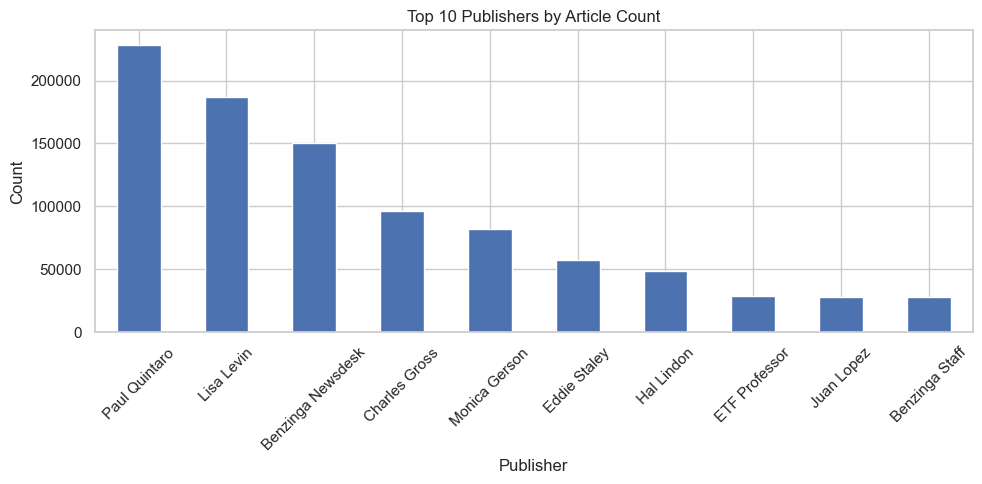

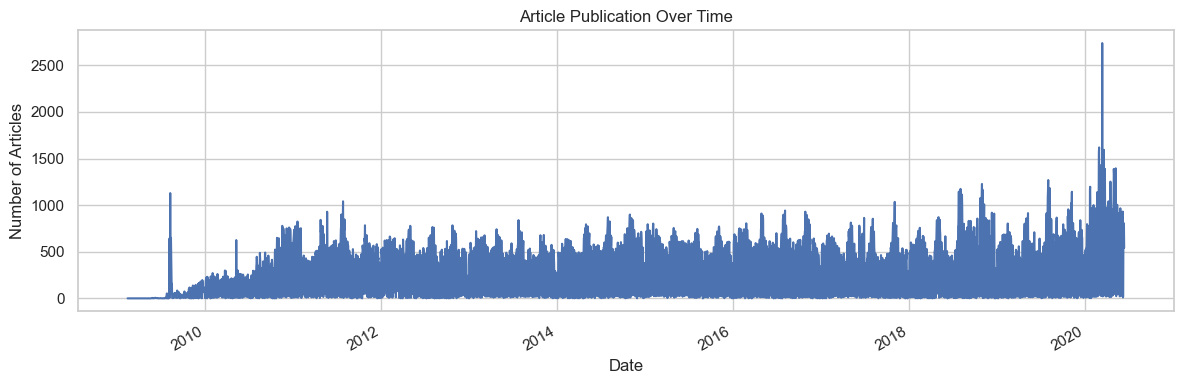

In [21]:
# 3. Descriptive Statistics
analyst_df['headline_length'] = analyst_df['headline'].apply(lambda x: len(str(x).split()))

# Basic stats on headline length
print("Headline Length Stats:")
print(analyst_df['headline_length'].describe())

# Articles per publisher
publisher_counts = analyst_df['publisher'].value_counts()
plt.figure(figsize=(10,5))
publisher_counts.head(10).plot(kind='bar')
plt.title('Top 10 Publishers by Article Count')
plt.ylabel('Count')
plt.xlabel('Publisher')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Articles over time
# Extract date component (without time) using normalize()
analyst_df['date_only'] = analyst_df['date'].dt.normalize()
date_counts = analyst_df['date_only'].value_counts().sort_index()

plt.figure(figsize=(12,4))
date_counts.plot()
plt.title('Article Publication Over Time')
plt.ylabel('Number of Articles')
plt.xlabel('Date')
plt.tight_layout()
plt.show()


In [22]:
# 4. Text Analysis - Topic Modeling (LDA)
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    tokens = [word for word in text.split() if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

analyst_df['cleaned_headline'] = analyst_df['headline'].apply(preprocess)

# Vectorize
vectorizer = CountVectorizer(max_df=0.9, min_df=10)
doc_term_matrix = vectorizer.fit_transform(analyst_df['cleaned_headline'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(doc_term_matrix)

# Display topics
words = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx + 1}:")
    print([words[i] for i in topic.argsort()[-10:]])
    print()


Topic 1:
['neutral', 'update', 'initiates', 'downgrades', 'raises', 'maintains', 'target', 'announces', 'price', 'buy']

Topic 2:
['oil', 'etfs', 'several', 'lower', 'higher', 'scheduled', 'companies', 'trading', 'earnings', 'shares']

Topic 3:
['industry', 'downgrades', 'upgrades', 'markets', 'movers', 'biggest', 'stocks', 'market', 'benzingas', 'top']

Topic 4:
['revenue', 'sees', 'estimate', 'moving', 'stocks', 'session', 'sales', 'reports', 'eps', 'est']

Topic 5:
['lows', 'set', 'option', 'alert', 'highs', 'hit', 'says', 'new', 'week', 'stocks']



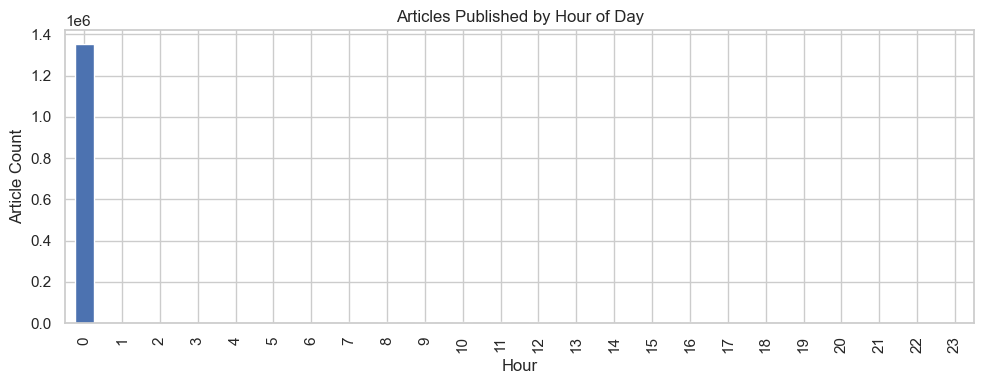

In [23]:
# 5. Time-of-day analysis
analyst_df['hour'] = analyst_df['date'].dt.hour

plt.figure(figsize=(10,4))
analyst_df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Articles Published by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Article Count")
plt.tight_layout()
plt.show()


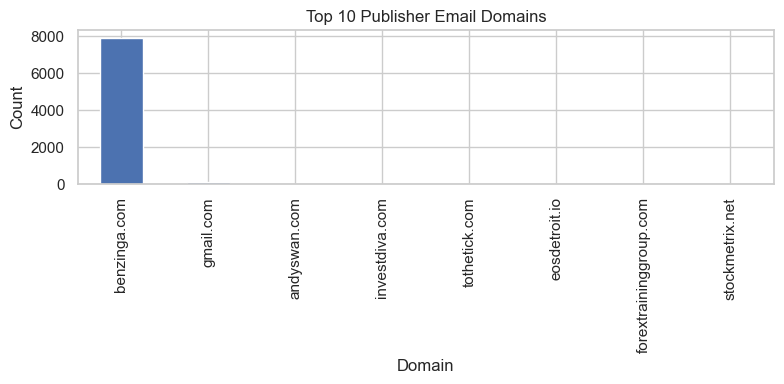

In [24]:
# 6. Publisher Email/Domain Analysis
if analyst_df['publisher'].str.contains("@").any():
    analyst_df['domain'] = analyst_df['publisher'].str.extract(r'@([\w\.-]+)')
    domain_counts = analyst_df['domain'].value_counts()

    plt.figure(figsize=(8,4))
    domain_counts.head(10).plot(kind='bar')
    plt.title("Top 10 Publisher Email Domains")
    plt.ylabel("Count")
    plt.xlabel("Domain")
    plt.tight_layout()
    plt.show()
else:
    print("No email-style publishers found.")


In [25]:
# 7. Financial data load example
stock_data = {}
base_path = "data/raw/yfinance_data"

for filename in os.listdir(base_path):
    if filename.endswith(".csv"):
        ticker = filename.split("_")[0]
        df = pd.read_csv(os.path.join(base_path, filename), parse_dates=["Date"])
        stock_data[ticker] = df
        print(f"{ticker}: {df.shape}")

# Preview AAPL data
stock_data['AAPL'].head()


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/raw/yfinance_data'